#MTH 5000 – Applied Forecasting of Financial Data
##Lecture 5: Time Series Forecasting Frameworks
---
Topics

*  1. Interpreting Time Series Decompositions
*  2. Additive Decomposition
*  3. Multiplicative Decomposition
*  4. Log Transformation
*  5. Log Decomposition


In [ ]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import seasonal_decompose

Saving Forecasting_Cleaned.csv to Forecasting_Cleaned.csv


In [ ]:
# Load dataset
df = pd.read_csv("Forecasting_Cleaned.csv")

In [ ]:
df.head()

,Date,Close,High,Low,Open,Volume,Return,Open_Close_Diff,High_Low,Abs_Return
0,2015-01-01,14.921,15.738,14.619,15.629,234334000,NaN,0.708,1.118,NaN
1,2015-01-08,14.663,15.157,14.325,15.016,375546000,-0.017,0.352,0.832,0.017
2,2015-01-15,14.863,15.300,14.262,14.700,420752000,0.014,-0.163,1.038,0.014
3,2015-01-22,15.196,15.847,15.000,15.000,380256000,0.022,-0.196,0.847,0.022
4,2015-01-29,18.237,18.391,14.967,15.236,1062542000,0.200,-3.001,3.425,0.200


In [ ]:
print("Columns in dataset:")
print(df.columns)

Columns in dataset:
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Return',
       'Open_Close_Diff', 'High_Low', 'Abs_Return'],
      dtype='object')


In [ ]:
# Select the main series (e.g., Close price)
ts = df['Close']

ts.head()

,Close
0,14.921
1,14.663
2,14.863
3,15.196
4,18.237


# 1. Interpreting Time Series Decompositions


Time series decomposition breaks down a time series into several components, typically:

1.  **Trend**: The long-term progression of the series, indicating whether the series is increasing, decreasing, or remaining stable over time.
2.  **Seasonal**: Patterns that repeat over a fixed period (e.g., daily, weekly, monthly, yearly). In our case, with `period=52` for weekly data, this represents yearly seasonality.
3.  **Residual (or Irregular)**: The random variation or noise in the series after removing the trend and seasonal components. It's what's left unexplained by the other two components.


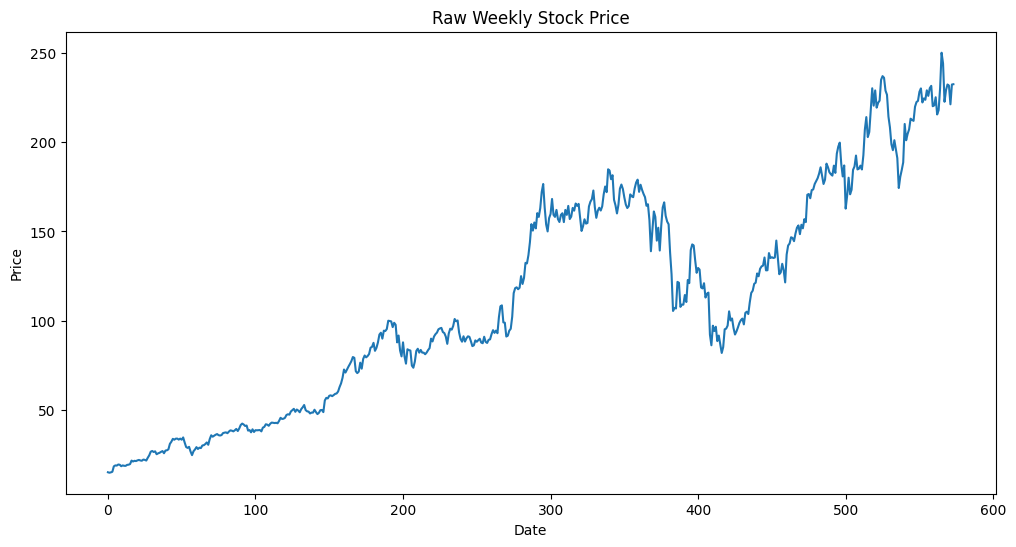

In [ ]:
#Visualize Raw Weekly Stock Price
plt.figure(figsize=(12,6))
plt.plot(ts)
plt.title('Raw Weekly Stock Price')
plt.xlabel('Date')
plt.ylabel('Price')
plt.show()



# 2. Additive Decomposition

In an additive model, the components are summed together:

`Y(t) = Trend(t) + Seasonal(t) + Residual(t)`

This model is appropriate when the magnitude of the seasonal fluctuations or the variation around the trend does not increase or decrease with the level of the time series.

*   **Observed**: Your original time series.
*   **Trend**: Shows the general upward movement of the stock price over the years.
*   **Seasonal**: Displays the repeating weekly/yearly pattern in the stock price. Its magnitude appears relatively consistent over time.
*   **Residual**: Represents the unpredictable fluctuations after removing the trend and seasonality. This component helps assess how well the model captures the underlying patterns.


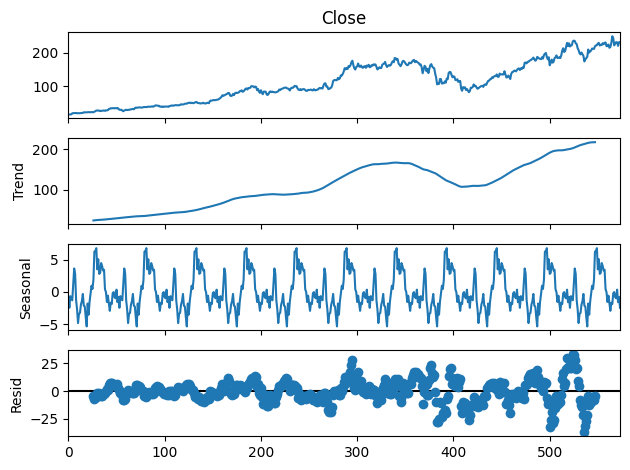

Additive Decompositon


In [ ]:
#Additive Decomposition
decomp_add = seasonal_decompose(ts, model='additive', period=52)  # weekly data, approx 1 year,
decomp_add.plot()
plt.show()
print("Additive Decompositon")

 This model assumes seasonal fluctuations remain constant in size (roughly $\pm 5$ units) regardless of the price, but the Residual plot shows increasing volatility over time, suggesting this model underfits the growing price swings.

# 3. Multiplicative Decomposition

In a multiplicative model, the components are multiplied together:

$Y_t = Trend_t * Seasonal_t * Residual_t$

This model is suitable when the magnitude of the seasonal fluctuations or the variation around the trend changes proportionally with the level of the time series. For example, if seasonal variations become larger as the series' overall level increases.

*   **Observed**: Your original time series.
*   **Trend**: Similar to the additive model, it captures the long-term direction.
*   **Seasonal**: In this model, the seasonal component is often a factor. If the seasonal fluctuations grow larger as the stock price increases, this model might be more appropriate. However, looking at your plot, the seasonal amplitude seems somewhat stable initially, and then grows with the series, suggesting a multiplicative model might be a better fit, or that the log transformation is a good idea.
*   **Residual**: Again, the unexplained variation. If the residuals in the multiplicative model are more constant across the series than in the additive model, it suggests a better fit.

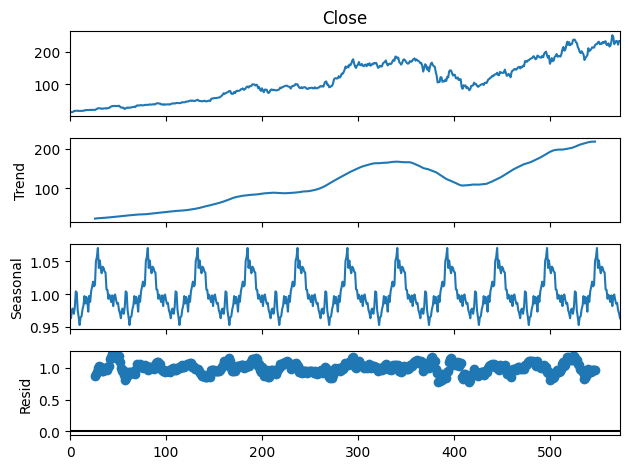

Multiplicativeitive Decompositon


In [ ]:
#Multiplicative Decomposition
decomp_add = seasonal_decompose(ts, model='multiplicative', period=52)  # weekly data, approx 1 year,
decomp_add.plot()
plt.show()
print("Multiplicativeitive Decompositon")

This interprets seasonality as a percentage (roughly $95\%$ to $105\%$) of the trend, which better accounts for the fact that price wiggles get larger as the stock price climbs toward 200.

# 4. Log Transformation

Applying a log transformation (`np.log(ts)`) to a time series is a common technique used for several reasons:

*   **Stabilize Variance**: Often, the variability of a time series increases with its level. Taking the logarithm can help stabilize this increasing variance, making the fluctuations more constant over time. This is evident in our `Log Transformed Weekly Stock Close Price` plot, where the amplitude of oscillations appears more consistent than in the raw series.
*   **Convert Multiplicative to Additive**: A multiplicative relationship $Y = T * S * R$ becomes additive after a log transformation: $\log(Y) = \log(T) + \log(S) + \log(R)$. This allows the use of additive decomposition methods, which are often simpler and more robust, even if the underlying process is multiplicative.
*   **Make Data More Normal**: Log transformation can help make the distribution of the data more symmetric and closer to a normal distribution, which can be beneficial for certain statistical models.


In [ ]:
#Log Transform
ts_log = np.log(ts)
ts_log

,Close
0,2.702770
1,2.685327
2,2.698875
3,2.721032
4,2.903452
...,...
569,5.448374
570,5.445789
571,5.399384
572,5.448374


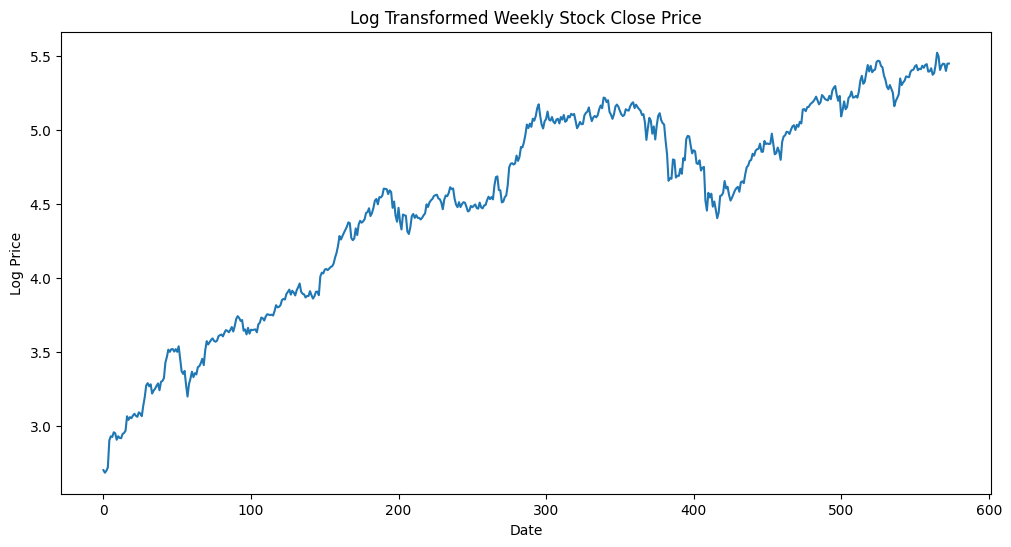

In [ ]:
plt.figure(figsize=(12,6))
plt.plot(ts_log)
plt.title('Log Transformed Weekly Stock Close Price')
plt.xlabel('Date')
plt.ylabel('Log Price')
plt.show()

# 5. Log Decompositon

When you decompose the log-transformed series using an *additive* model, you are effectively performing a multiplicative decomposition on the original series. This is often preferred because it leverages the benefits of log transformation (variance stabilization) while still capturing proportional relationships.

*   **Trend**: Shows the trend of the log-transformed series.
*   **Seasonal**: The seasonal component of the log-transformed series. This indicates proportional seasonal effects on the original scale.
*   **Residual**: The residuals after removing the log-transformed trend and seasonality. These should ideally be small, random, and have constant variance.



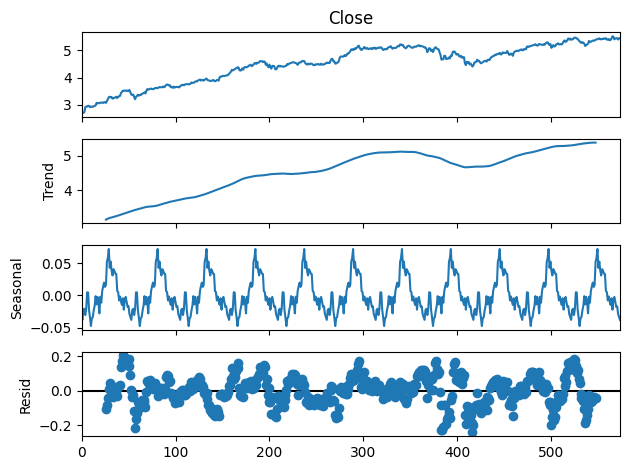

Decomposition of Log Series


In [ ]:
#Decompose Log Series (additive after log)
decomp_log = seasonal_decompose(ts_log, model='additive', period=52)
decomp_log.plot()
plt.show()
print('Decomposition of Log Series')


By compressing the price scale, this model stabilizes the variance into a consistent band of noise, making it the most mathematically sound choice for building a reliable forecast.

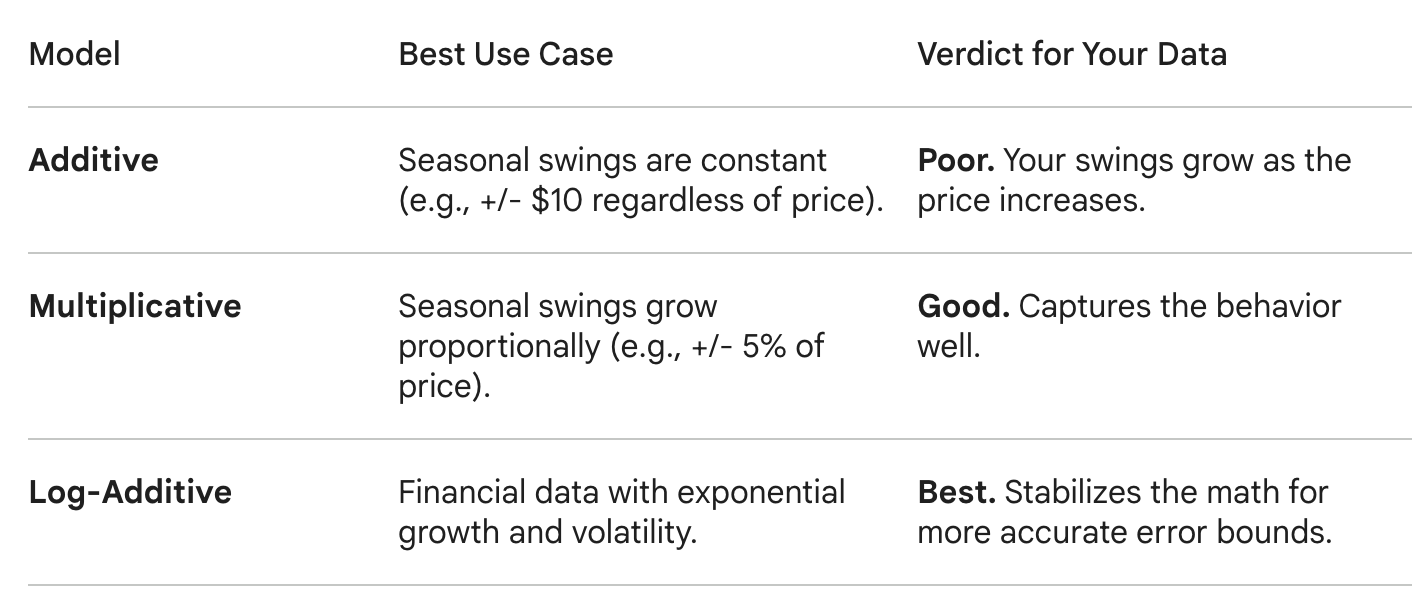

In summary, by analyzing these plots, we can understand the underlying long-term direction (trend), repeating patterns (seasonality), and the random fluctuations (residuals) of your stock price data. Breaking the series into parts (trend, seasonality, and noise) makes it easier to understand what’s really happening.

The log transformation and subsequent decomposition provide a robust way to analyze time series where variability grows with the series' level. Basically the log helps when the ups and downs get bigger as the values increase.